# 04b — ML Part 1 (Ordinal Classification)

Companion to `04_ml_part1_price_and_value_retention.ipynb`. Step 4.4 in 04 trains a continuous regressor on `max_discount_ever / 100`. This notebook reframes the same target as an **ordinal classification** problem on 5% bins.

**Why split it out:** the regression and ordinal classifier are different model families with different evaluation metrics — keeping them in the same flow muddied the narrative. Each notebook now tells a single coherent story:

- **04** → continuous prediction of peak discount (regression)
- **04b** → tier-aware prediction with bin-distance metrics (this notebook)

**Why 5% bins:** Steam discount values cluster at standardized publisher tiers (10%, 25%, 50%, 66%, 75%, 90%, ...). A continuous regressor wastes capacity predicting between tiers; an ordinal classifier can match the actual data structure. 5% bins are tight enough to preserve resolution but wide enough that most bins contain meaningful counts.

**Why bin-distance metrics, not just accuracy:** predicting bin 14 (70%) when truth is bin 15 (75%) is a near-miss; predicting bin 1 (5%) is a catastrophic error. Standard accuracy treats both equally. We report:
- **Exact accuracy** — predicted bin matches true bin
- **Within ±1 bin** — predicted within ±5 percentage points of true
- **Within ±2 bins** — within ±10 points
- **Within ±4 bins** — within ±20 points
- **Mean absolute bin error (MABE)** — average bin-distance

## Setup

In [1]:
import sys
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

# Bootstrap: make src importable
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebook_setup import setup_notebook
from src.plot_style import apply_style, PALETTE, TIER_COLORS

conn, paths = setup_notebook()

# Load cleaned_games + backfill columns the cleaning step doesn't yet persist
df = pd.read_sql_query('SELECT * FROM cleaned_games', conn)
print(f'Loaded {len(df):,} rows from cleaned_games')

if 'ever_discounted' not in df.columns:
    ever_disc = pd.read_sql_query(
        'SELECT appid, MAX(CASE WHEN cut > 0 THEN 1 ELSE 0 END) AS ever_discounted '
        'FROM price_history GROUP BY appid', conn,
    )
    df = df.merge(ever_disc, on='appid', how='left')

if 'achievements_total' not in df.columns:
    ach = pd.read_sql_query('SELECT appid, achievements_total FROM games', conn)
    df = df.merge(ach, on='appid', how='left')

if 'max_discount_ever' not in df.columns:
    mde = pd.read_sql_query(
        'SELECT appid, MAX(cut) AS max_discount_ever '
        'FROM price_history GROUP BY appid', conn,
    )
    df = df.merge(mde, on='appid', how='left')

if 'publisher' not in df.columns:
    pub = pd.read_sql_query('SELECT appid, publisher FROM games', conn)
    df = df.merge(pub, on='appid', how='left')

df['ever_discounted']    = df['ever_discounted'].fillna(0).astype(int)
df['achievements_total'] = df['achievements_total'].fillna(0).astype(int)
df['max_discount_ever']  = df['max_discount_ever'].fillna(0).astype(float)
df['publisher']          = df['publisher'].fillna('Unknown').astype(str)
df['log_total_reviews']  = np.log1p(df['total_reviews'])

Connected to: c:\Users\Sam\Documents\College\2026 Spring Term\DMW\Y2T2-Final-Project\data\steam.db
Tables (15): ['app_list', 'cleaned_discount_panel', 'cleaned_games', 'cleaned_sale_events', 'game_categories', 'game_genres', 'games', 'itad_mapping', 'player_counts', 'price_history', 'review_timestamps', 'reviews_summary', 'steamcharts_history', 'steamspy', 'steamspy_tags']
Loaded 4,946 rows from cleaned_games


## Step 1: Filter + Feature Setup

Same data filtering and feature setup as 04 — kept in sync so this notebook can be run independently. Filter to games with observed sale history (`max_discount_ever > 0`) so we don't train on rows where ITAD coverage is too sparse to support a peak-discount label.

In [2]:
df_model = df[df['initial_price'] > 0].copy()

NUM_FEATURES = [
    'days_since_release',
    'initial_price',
    'review_score',
    'log_total_reviews',
    'log_ownership',
    'achievements_total',
]
CAT_FEATURES = [
    'primary_genre',
    'developer_tier',
    'price_tier',
    'is_multiplayer',
    'has_controller_support',
    'release_month',
    'player_engagement',
]
PUB_FEATURE = ['publisher']  # high-cardinality, target-encoded

required = NUM_FEATURES + CAT_FEATURES + PUB_FEATURE + ['max_discount_ever']
mask_features = df_model[required].notna().all(axis=1)
mask_observed = df_model['max_discount_ever'] > 0

print('Filter funnel:')
print(f'  cleaned_games                            : {len(df):>5,}')
print(f'  + initial_price > 0                       : {len(df_model):>5,}')
print(f'  + non-null required features              : {mask_features.sum():>5,}')
print(f'  + has observed sale history (cut > 0)    : {(mask_features & mask_observed).sum():>5,}')

df_clean = df_model[mask_features & mask_observed].copy()
print(f'\nFinal modelling dataset: {len(df_clean):,} games')

# Preprocessor with TargetEncoder for publisher
preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                                                         NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore'),                                   CAT_FEATURES),
    ('pub', TargetEncoder(smooth=10.0, target_type='continuous', random_state=42),    PUB_FEATURE),
])

Filter funnel:
  cleaned_games                            : 4,946
  + initial_price > 0                       : 4,022
  + non-null required features              : 4,003
  + has observed sale history (cut > 0)    : 3,968

Final modelling dataset: 3,968 games


## Step 2: Build 5% Discount Bins

Cut `max_discount_ever / 100` into 20 bins of width 0.05 — bin 0 = [0, 5%), bin 1 = [5%, 10%), ..., bin 19 = [95%, 100%]. Most observations will land in the bins matching standard Steam tiers (5, 10, 15, 25, 33, 50, 66, 75, 90).

In [3]:
BIN_EDGES   = np.arange(0, 1.05, 0.05)        # 0.00, 0.05, ..., 1.00
BIN_CENTERS = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2
N_BINS      = len(BIN_EDGES) - 1

df_clean['discount_bin'] = pd.cut(
    df_clean['max_discount_ever'] / 100,
    bins=BIN_EDGES, labels=False, include_lowest=True,
).astype(int)

# Inspect bin distribution
counts = df_clean['discount_bin'].value_counts().sort_index()
print(f'Target — {N_BINS} bins of 5% width each')
print(f'Populated bins: {len(counts)} / {N_BINS}')
print()
print('Bin distribution:')
for bin_id, n in counts.items():
    pct_low  = BIN_EDGES[bin_id]   * 100
    pct_high = BIN_EDGES[bin_id+1] * 100
    bar = '█' * max(1, int(n / counts.max() * 40))
    print(f'  bin {bin_id:>2} ({pct_low:>3.0f}-{pct_high:>3.0f}%):  {n:>4,}  {bar}')

Target — 20 bins of 5% width each
Populated bins: 19 / 20

Bin distribution:
  bin  1 (  5- 10%):    12  █
  bin  2 ( 10- 15%):     6  █
  bin  3 ( 15- 20%):    58  ██
  bin  4 ( 20- 25%):    51  ██
  bin  5 ( 25- 30%):    82  ███
  bin  6 ( 30- 35%):    76  ███
  bin  7 ( 35- 40%):   109  ████
  bin  8 ( 40- 45%):    28  █
  bin  9 ( 45- 50%):   289  ████████████
  bin 10 ( 50- 55%):    73  ███
  bin 11 ( 55- 60%):   206  ████████
  bin 12 ( 60- 65%):    74  ███
  bin 13 ( 65- 70%):   305  ████████████
  bin 14 ( 70- 75%):   547  ███████████████████████
  bin 15 ( 75- 80%):   550  ███████████████████████
  bin 16 ( 80- 85%):   338  ██████████████
  bin 17 ( 85- 90%):   946  ████████████████████████████████████████
  bin 18 ( 90- 95%):   138  █████
  bin 19 ( 95-100%):    80  ███


## Step 3: Train/Test Split

80/20 stratified split on the binned target so every observed bin appears in both train and test sets proportionally.

In [4]:
X = df_clean[NUM_FEATURES + CAT_FEATURES + PUB_FEATURE]
y = df_clean['discount_bin']

# Stratified split — preserves the bin distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)

print(f'Train: {len(X_train):,}  Test: {len(X_test):,}')
print(f'Train bin range: {y_train.min()} - {y_train.max()}  ({y_train.nunique()} unique bins)')

Train: 3,174  Test: 794
Train bin range: 1 - 19  (19 unique bins)


## Step 4: Train Models + Bin-distance Metrics

Compare a Dummy stratified baseline against a tuned Random Forest classifier. Reporting exact accuracy plus the bin-distance metrics that match how buyers actually use the predictions.

In [5]:
def evaluate_ordinal(name, predictions, y_true):
    distances = np.abs(predictions - y_true.values)
    return {
        'Model':                       name,
        'Exact (within 0%)':           (distances == 0).mean(),
        'Within +/- 1 bin (5%)':       (distances <= 1).mean(),
        'Within +/- 2 bins (10%)':     (distances <= 2).mean(),
        'Within +/- 4 bins (20%)':     (distances <= 4).mean(),
        'MABE (bins)':                 distances.mean(),
        'MABE (pp)':                   distances.mean() * 5,
    }

results = []
predictions = {}

# Dummy baseline — random with class frequencies
dummy = Pipeline([
    ('prep', preprocessor),
    ('model', DummyClassifier(strategy='stratified', random_state=42)),
])
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)
predictions['Dummy (stratified)'] = pred_dummy
results.append(evaluate_ordinal('Dummy (stratified)', pred_dummy, y_test))

# Random Forest classifier
rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_leaf=3,
        class_weight='balanced_subsample', random_state=42, n_jobs=-1,
    )),
])
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
predictions['Random Forest'] = pred_rf
results.append(evaluate_ordinal('Random Forest', pred_rf, y_test))

results_df = pd.DataFrame(results).set_index('Model')
print('=== Ordinal classification results ===')
display(results_df.round(3))

# Sanity check vs Dummy
dummy_within1 = results_df.loc['Dummy (stratified)', 'Within +/- 1 bin (5%)']
rf_within1    = results_df.loc['Random Forest',     'Within +/- 1 bin (5%)']
lift          = (rf_within1 - dummy_within1) / dummy_within1 * 100
print(f'\nRF beats Dummy by {lift:+.0f}% on within-+/-1-bin accuracy.')
print('  (positive = real signal; near-0 = features are noise)')

=== Ordinal classification results ===


,Exact (within 0%),Within +/- 1 bin (5%),Within +/- 2 bins (10%),Within +/- 4 bins (20%),MABE (bins),MABE (pp)
Model,,,,,,
Dummy (stratified),0.110,0.276,0.432,0.670,3.957,19.786
Random Forest,0.257,0.450,0.639,0.825,2.548,12.739



RF beats Dummy by +63% on within-+/-1-bin accuracy.
  (positive = real signal; near-0 = features are noise)


## Step 5: Confusion Matrix + Error Distribution

The confusion matrix shows where the RF predicts versus actual. Diagonal cells = correct; near-diagonal cells = small errors; off-diagonal cells = big misses. The error histogram tells you what fraction of predictions land within how many bins of true.

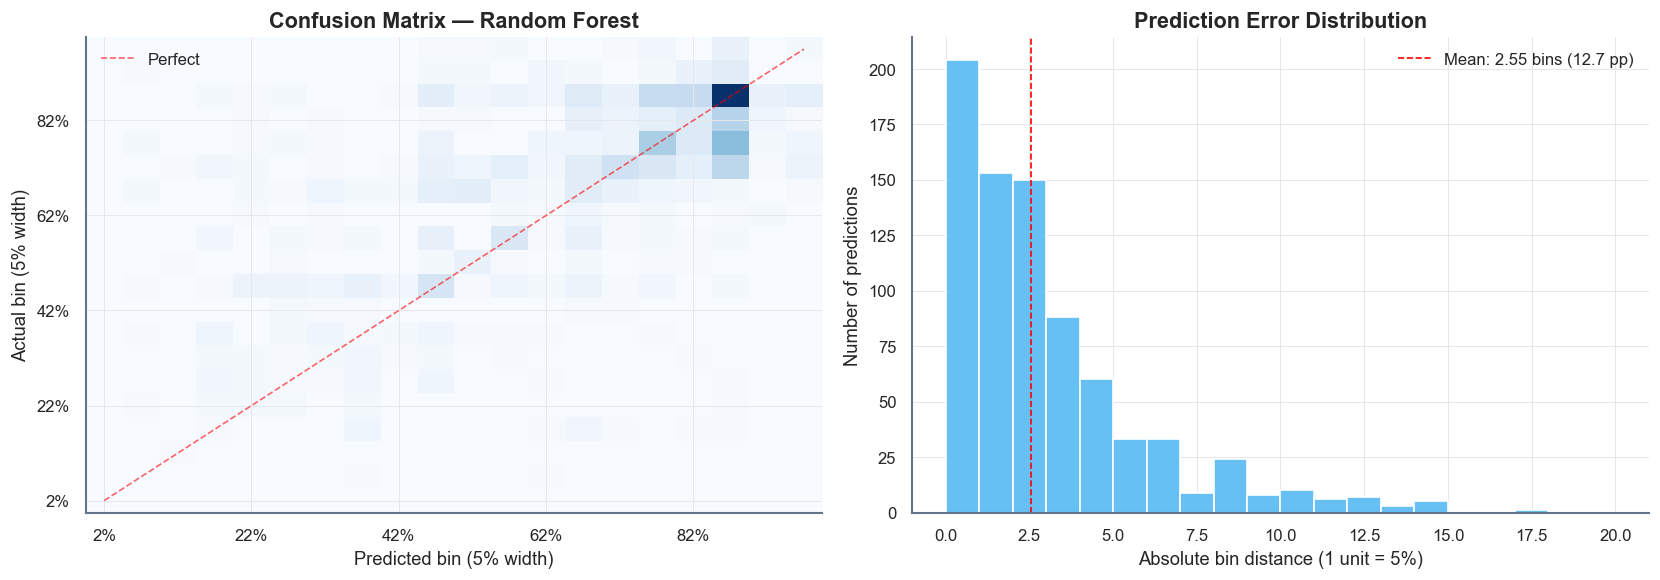

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion-style heatmap (RF only — the model that matters)
cm = confusion_matrix(y_test, predictions['Random Forest'], labels=list(range(N_BINS)))
axes[0].imshow(cm, cmap='Blues', aspect='auto', origin='lower')
axes[0].set_xlabel('Predicted bin (5% width)')
axes[0].set_ylabel('Actual bin (5% width)')
axes[0].set_title('Confusion Matrix — Random Forest')
axes[0].plot([0, N_BINS-1], [0, N_BINS-1], 'r--', linewidth=1, alpha=0.6, label='Perfect')
axes[0].legend(loc='upper left')
tick_positions = np.arange(0, N_BINS, 4)
tick_labels = [f'{int(BIN_CENTERS[i]*100)}%' for i in tick_positions]
axes[0].set_xticks(tick_positions); axes[0].set_xticklabels(tick_labels)
axes[0].set_yticks(tick_positions); axes[0].set_yticklabels(tick_labels)

# Bin-distance error histogram
distances_rf = np.abs(predictions['Random Forest'] - y_test.values)
axes[1].hist(distances_rf, bins=range(N_BINS + 1), color=PALETTE['cyan'], edgecolor='white')
axes[1].set_xlabel('Absolute bin distance (1 unit = 5%)')
axes[1].set_ylabel('Number of predictions')
axes[1].set_title('Prediction Error Distribution')
axes[1].axvline(distances_rf.mean(), color='red', linestyle='--', linewidth=1,
                label=f'Mean: {distances_rf.mean():.2f} bins ({distances_rf.mean()*5:.1f} pp)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Discussion

The RF classifier maps each game to one of 20 discount-tier bins (5% wide). The headline metrics map to actionable buyer guidance:

- **Within ±1 bin** is the most useful number for the report: "the model predicts peak discount within ±5 percentage points of true X% of the time."
- **MABE in percentage points** translates to: "on average, the model is off by Y points."

**Caveats:**
- Bin distribution is heavily imbalanced — most games land in the 50-75% range, with very few in the extremes. `class_weight='balanced_subsample'` partially compensates but tail bins (e.g., 95-100%) will still have weak per-bin accuracy.
- The 5% bin width was a deliberate choice — wider bins (e.g., 10%) would inflate exact-match accuracy at the cost of resolution. A binary 'deep discount? yes/no' framing has a comparable predictive ceiling but loses the tier information.
- Steam's actual discount values cluster at non-uniform tiers (25, 33, 50, 66, 75, 90 — not multiples of 5), so some 5% bins will always be near-empty by data structure rather than model error.

**For the report:** the regression in 04 and this ordinal classifier are complementary, not redundant. Use the regression's continuous output for ranking games (sort by predicted discount), and the ordinal classifier's bin output for explanatory framing ("most AAA premium games are predicted to peak in the 50-75% range").

In [7]:
conn.close()
print('connection closed')

connection closed
